In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# load dataset 
df = pd.read_csv("space_launches.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
  Flight Number    Launch Date Launch Time       Launch Site Vehicle Type  \
0          F1-1  24 March 2006       22:30  Marshall Islands     Falcon 1   
1          F1-2  21 March 2007       01:10  Marshall Islands     Falcon 1   
2          F1-3  3 August 2008       03:34  Marshall Islands     Falcon 1   
3          F1-3  3 August 2008       03:34  Marshall Islands     Falcon 1   
4          F1-3  3 August 2008       03:34  Marshall Islands     Falcon 1   

         Payload Name             Payload Type  Payload Mass (kg)  \
0         FalconSAT-2       Research Satellite               19.5   
1             DemoSat                      NaN                NaN   
2         Trailblazer  Communication Satellite                NaN   
3  PRESat, NanoSail-D      Research Satellites                8.0   
4           Explorers            Human Remains                NaN   

  Payload Orbit Customer Name Customer Type Customer Country Mission Outcome  \
0           Na

In [6]:
#dataset information
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(41, 16)

Column Names:
Index(['Flight Number', 'Launch Date', 'Launch Time', 'Launch Site',
       'Vehicle Type', 'Payload Name', 'Payload Type', 'Payload Mass (kg)',
       'Payload Orbit', 'Customer Name', 'Customer Type', 'Customer Country',
       'Mission Outcome', 'Failure Reason', 'Landing Type', 'Landing Outcome'],
      dtype='object')

Missing Values:
Flight Number         0
Launch Date           0
Launch Time           0
Launch Site           0
Vehicle Type          0
Payload Name          0
Payload Type          3
Payload Mass (kg)     8
Payload Orbit         5
Customer Name         2
Customer Type         2
Customer Country      2
Mission Outcome       0
Failure Reason       33
Landing Type         20
Landing Outcome      20
dtype: int64


In [11]:
#missing value handling
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Handle missing values only if they exist
if df.isnull().sum().sum() > 0:
    df = df.fillna("Unknown")
    print("Missing values handled.")
else:
    print("No missing values found.")

Missing Values:
Flight Number        0
Launch Date          0
Launch Time          0
Launch Site          0
Vehicle Type         0
Payload Name         0
Payload Type         0
Payload Mass (kg)    0
Payload Orbit        0
Customer Name        0
Customer Type        0
Customer Country     0
Mission Outcome      0
Failure Reason       0
Landing Type         0
Landing Outcome      0
dtype: int64
No missing values found.


In [13]:
#remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicates removed")
print(df)

Duplicates removed
   Flight Number        Launch Date Launch Time                  Launch Site  \
0           F1-1      24 March 2006       22:30             Marshall Islands   
1           F1-2      21 March 2007       01:10             Marshall Islands   
2           F1-3      3 August 2008       03:34             Marshall Islands   
3           F1-3      3 August 2008       03:34             Marshall Islands   
4           F1-3      3 August 2008       03:34             Marshall Islands   
5           F1-4  28 September 2008       23:15             Marshall Islands   
6           F1-5       14 July 2009       03:35             Marshall Islands   
7           F9-1        4 June 2010       18:45     Cape Canaveral AFS LC-40   
8           F9-2    8 December 2010       15:43     Cape Canaveral AFS LC-40   
9           F9-3        22 May 2012       07:44     Cape Canaveral AFS LC-40   
10          F9-4     8 October 2012       00:35     Cape Canaveral AFS LC-40   
11          F9-4     

In [17]:
# Convert Launch Date to datetime
df['Launch Date'] = pd.to_datetime(df['Launch Date'])

# Extract Year
df['Year'] = df['Launch Date'].dt.year

print(df[['Launch Date', 'Year']].head())

  Launch Date  Year
0  2006-03-24  2006
1  2007-03-21  2007
2  2008-08-03  2008
3  2008-08-03  2008
4  2008-08-03  2008


In [18]:
#launches per year
launches_per_year = df.groupby('Year').size()

print(launches_per_year.head())

Year
2006    1
2007    1
2008    4
2009    1
2010    2
dtype: int64


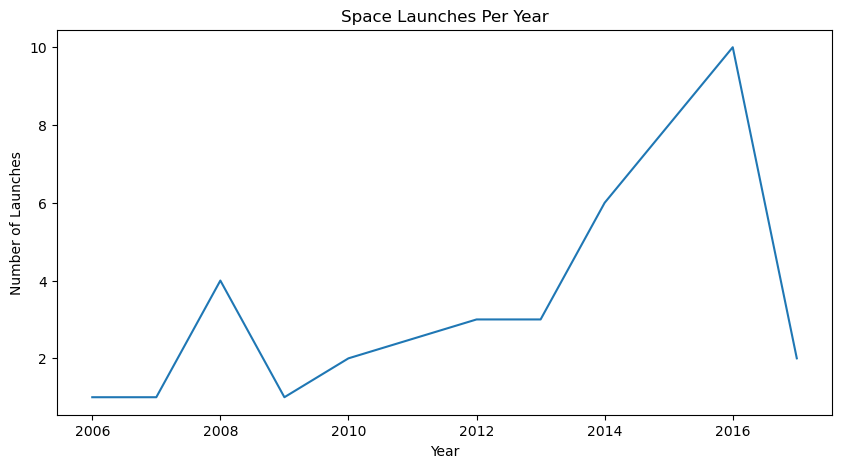

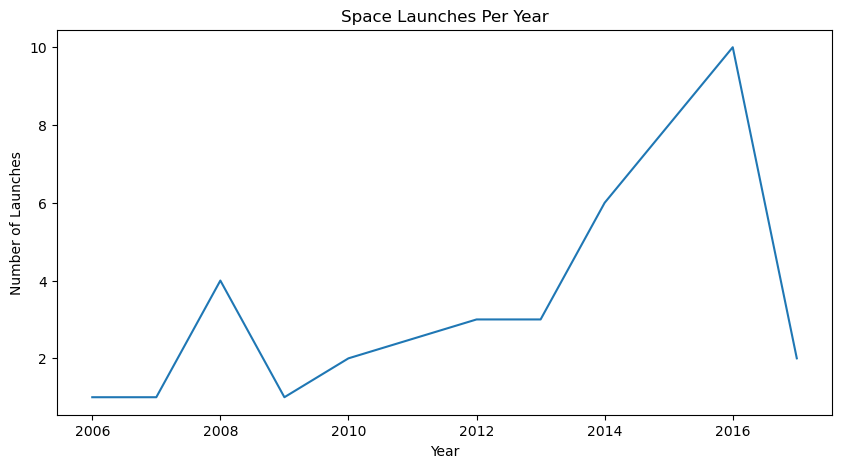

In [20]:
%matplotlib inline
plt.figure(figsize=(10,5))

launches_per_year.plot()

plt.title("Space Launches Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Launches")

plt.show()

<Figure size 800x500 with 0 Axes>

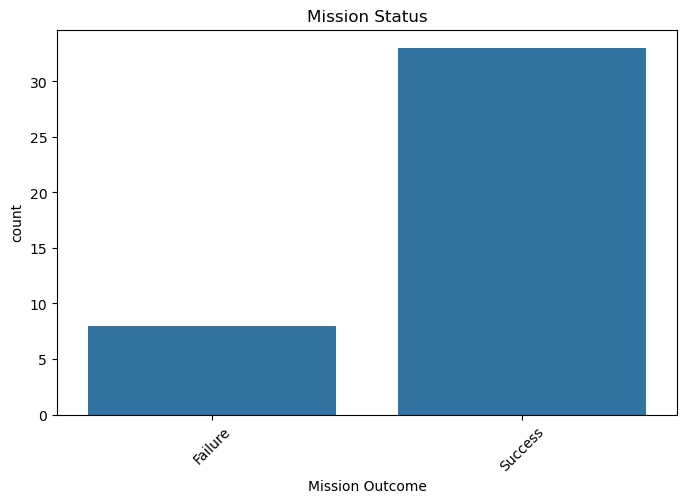

In [22]:
#mission status analysis
plt.figure(figsize=(8,5))

sns.countplot(
    x='Mission Outcome',
    data=df
)

plt.title("Mission Status")

plt.xticks(rotation=45)

plt.show()

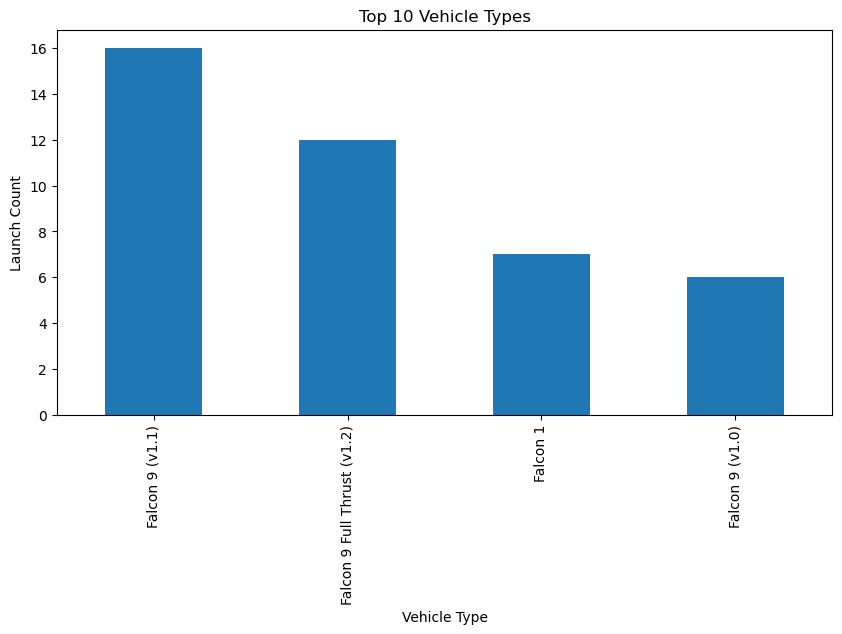

In [24]:
#Top Vehicles types
top_vehicles = df['Vehicle Type'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_vehicles.plot(kind='bar')

plt.title("Top 10 Vehicle Types")
plt.xlabel("Vehicle Type")
plt.ylabel("Launch Count")

plt.show()

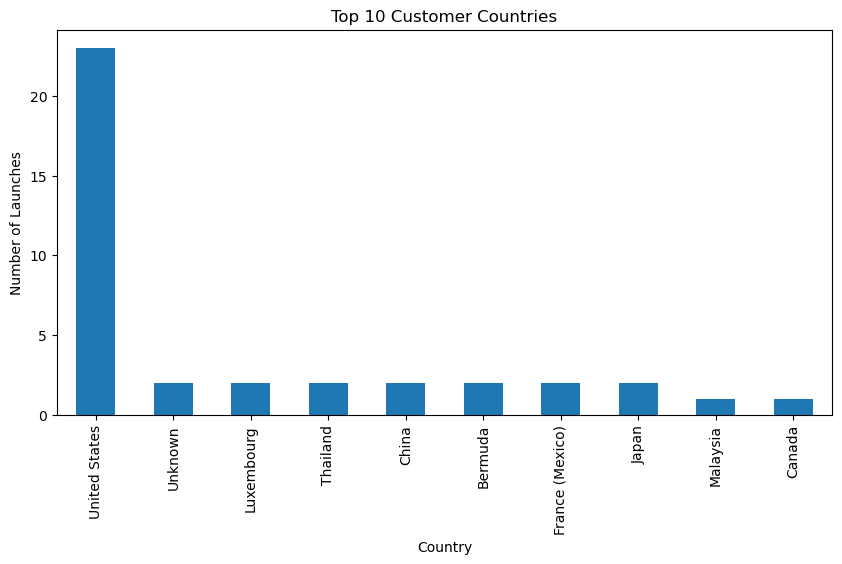

In [25]:
top_countries = df['Customer Country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title("Top 10 Customer Countries")
plt.xlabel("Country")
plt.ylabel("Number of Launches")

plt.show()

In [28]:
df['Launch Site'] = df['Customer Country'].str.split(',').str[-1]

In [30]:
#pivot table
pivot_table = pd.pivot_table(
    df,
    values='Vehicle Type',
    index='Year',
    columns='Mission Outcome',
    aggfunc='count',
    fill_value=0
)

print(pivot_table.head())

Mission Outcome  Failure  Success
Year                             
2006                   1        0
2007                   1        0
2008                   3        1
2009                   0        1
2010                   0        2


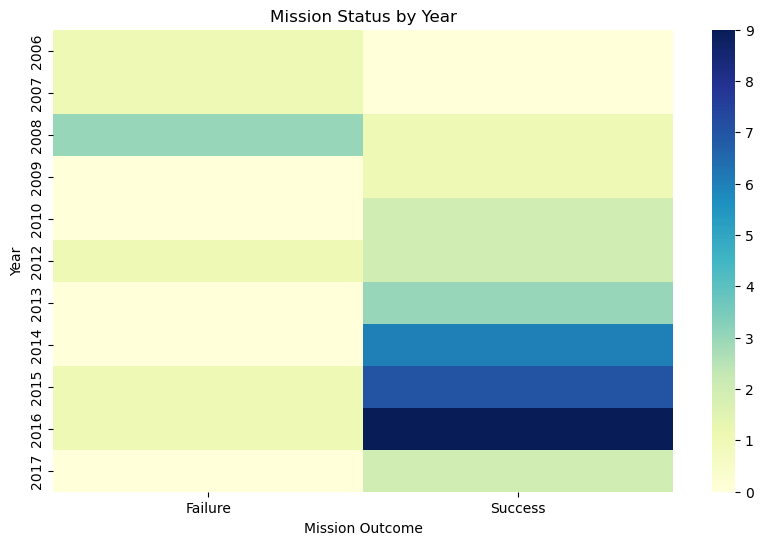

In [31]:
#heatmap from Pivot table
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_table,
    cmap="YlGnBu"
)

plt.title("Mission Status by Year")

plt.show()

In [32]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


2026-06-03 15:49:35.757 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 15:49:35.757 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 15:49:35.758 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 15:49:35.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 15:49:35.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 15:49:35.760 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 15:49:35.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 15:49:35.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [39]:
streamlit --version

NameError: name 'streamlit' is not defined